# Fase 8 — Agente PPO (Reinforcement Learning)

**Objetivo**: entrenar un agente **Proximal Policy Optimization** que aprenda una politica de trading sobre el spread Kalman, optimizando reward (PnL neto de costos).

**Por que PPO**:
- Estable y robusto (clip ratio evita updates destructivos).
- Sample-efficient para tareas con horizonte largo.
- Implementacion industrial en `stable-baselines3`.
- Funciona bien con acciones discretas (3 acciones) o continuas.

**Setup**:
- **Train env**: datos 2010-2018, episodios random de 252 dias (1 año).
- **Eval env**: datos 2022-presente, episodio fijo.
- **Total timesteps**: 100k (suficiente para ver convergencia en este problema).
- **Politica MLP**: 2 capas ocultas de 64 unidades.

**Anti-leakage**:
- El env de train solo ve el split 2010-2018. El test set nunca entra al entrenamiento.
- Las features causales ya estaban garantizadas en Fase 4.


In [1]:
import sys; sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')
import os
os.environ['SB3_DISABLE_TQDM'] = '1'
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from envs.pair_trading_env import PairTradingEnv
import torch
torch.manual_seed(42); np.random.seed(42)

DATA_DIR = Path('data')
MODELS_DIR = Path('models'); MODELS_DIR.mkdir(exist_ok=True)
LOGS_DIR = Path('logs'); LOGS_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(DATA_DIR / 'features_with_lstm.parquet')
print(f'Panel: {df.shape}')

train_df = df.loc[:'2018-12-31'].copy()
val_df   = df.loc['2019-01-01':'2021-12-31'].copy()
test_df  = df.loc['2022-01-01':].copy()
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')


Panel: (4051, 22)
Train: 2201 | Val: 757 | Test: 1093


## 8.1 Construccion de envs (train con random start, eval con start fijo)

In [2]:
def make_train_env():
    return Monitor(PairTradingEnv(train_df, cost_bps=5.0, turnover_penalty=1e-5,
                                  episode_len=252, random_start=True, seed=42))

def make_eval_env(d):
    return Monitor(PairTradingEnv(d, cost_bps=5.0, turnover_penalty=0.0,
                                  episode_len=len(d)-2, random_start=False))

train_env = DummyVecEnv([make_train_env])
val_env   = make_eval_env(val_df)
test_env  = make_eval_env(test_df)
print('Envs creadas. obs_space:', train_env.observation_space, '| act_space:', train_env.action_space)


Envs creadas. obs_space: Box(-inf, inf, (12,), float32) | act_space: Discrete(3)


## 8.2 Definicion del agente PPO

In [3]:
policy_kwargs = dict(net_arch=[64, 64])
model = PPO(
    policy='MlpPolicy',
    env=train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    verbose=0,
    seed=42,
)
print('PPO model creado. Politica:')
print(model.policy)
n_params = sum(p.numel() for p in model.policy.parameters())
print(f'Parametros totales: {n_params:,}')


PPO model creado. Politica:
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=12, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=12, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=3, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)
Parametros totales: 10,244


## 8.3 Entrenamiento (100k timesteps)

In [4]:
import time
TIMESTEPS = 100_000
t0 = time.time()
model.learn(total_timesteps=TIMESTEPS, progress_bar=False, log_interval=20)
elapsed = time.time() - t0
print(f'Entrenamiento finalizado en {elapsed:.1f}s ({TIMESTEPS} timesteps)')
model.save(str(MODELS_DIR / 'ppo_agent'))
print(f'Modelo guardado en {MODELS_DIR / "ppo_agent"}.zip')


Entrenamiento finalizado en 132.5s (100000 timesteps)
Modelo guardado en models\ppo_agent.zip


## 8.4 Evaluacion deterministica en val y test

In [5]:
def eval_policy(env, model, deterministic=True):
    obs, _ = env.reset()
    pnls, equities, positions, dates = [], [], [], []
    while True:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, r, term, trunc, info = env.step(action)
        pnls.append(r); equities.append(info['equity'])
        positions.append(info['position']); dates.append(info['date'])
        if term or trunc: break
    return np.array(pnls), np.array(equities), np.array(positions), dates

def metrics(pnl, eq):
    pnl = np.array(pnl)
    if len(pnl) == 0 or pnl.std() == 0:
        return dict(sharpe=0, ann_ret=0, ann_vol=0, max_dd=0, n=len(pnl))
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252)
    ann_ret = (1 + pnl).prod() ** (252/len(pnl)) - 1
    ann_vol = pnl.std() * np.sqrt(252)
    eq = np.array(eq)
    roll_max = np.maximum.accumulate(eq)
    dd = eq / roll_max - 1
    return dict(sharpe=sharpe, ann_ret=ann_ret, ann_vol=ann_vol, max_dd=dd.min(), n=len(pnl))

print('--- VALIDATION (2019-2021) ---')
p_va, eq_va, pos_va, d_va = eval_policy(val_env, model)
m_va = metrics(p_va, eq_va)
for k, v in m_va.items(): print(f'  {k}: {v:.4f}' if isinstance(v,float) else f'  {k}: {v}')

print('\n--- TEST (2022+) ---')
p_te, eq_te, pos_te, d_te = eval_policy(test_env, model)
m_te = metrics(p_te, eq_te)
for k, v in m_te.items(): print(f'  {k}: {v:.4f}' if isinstance(v,float) else f'  {k}: {v}')

print(f'\nDistribucion de posiciones (val): {dict(zip(*np.unique(pos_va, return_counts=True)))}')
print(f'Distribucion de posiciones (test): {dict(zip(*np.unique(pos_te, return_counts=True)))}')


--- VALIDATION (2019-2021) ---


  sharpe: 0.1149
  ann_ret: 0.0027
  ann_vol: 0.2011
  max_dd: -0.3437
  n: 755

--- TEST (2022+) ---


  sharpe: -0.4632
  ann_ret: -0.0828
  ann_vol: 0.1591
  max_dd: -0.3608
  n: 1091

Distribucion de posiciones (val): {np.int64(-1): np.int64(214), np.int64(1): np.int64(541)}
Distribucion de posiciones (test): {np.int64(-1): np.int64(264), np.int64(1): np.int64(827)}


## 8.5 Equity curves del agente PPO

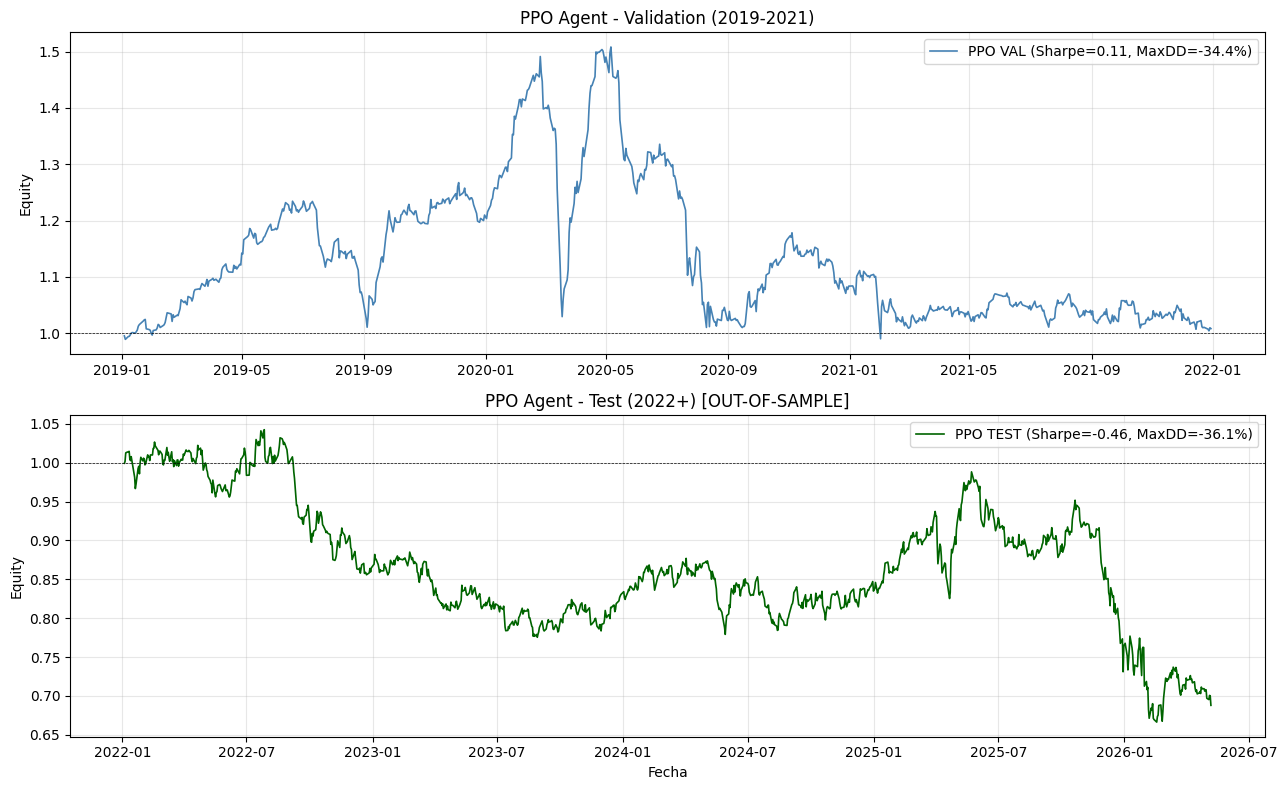

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

ax = axes[0]
val_dates = pd.to_datetime([s[:10] for s in d_va])
ax.plot(val_dates, eq_va, label=f'PPO VAL (Sharpe={m_va["sharpe"]:.2f}, MaxDD={m_va["max_dd"]*100:.1f}%)',
        color='steelblue', lw=1.2)
ax.axhline(1, color='black', ls='--', lw=0.5)
ax.set_title('PPO Agent - Validation (2019-2021)')
ax.set_ylabel('Equity'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
test_dates = pd.to_datetime([s[:10] for s in d_te])
ax.plot(test_dates, eq_te, label=f'PPO TEST (Sharpe={m_te["sharpe"]:.2f}, MaxDD={m_te["max_dd"]*100:.1f}%)',
        color='darkgreen', lw=1.2)
ax.axhline(1, color='black', ls='--', lw=0.5)
ax.set_title('PPO Agent - Test (2022+) [OUT-OF-SAMPLE]')
ax.set_xlabel('Fecha'); ax.set_ylabel('Equity'); ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'ppo_equity.png', dpi=120)
plt.show()


## 8.6 Persistencia

In [7]:
import json
ppo_results = {
    'val': {**m_va, 'final_equity': float(eq_va[-1])},
    'test': {**m_te, 'final_equity': float(eq_te[-1])},
}
# floats compatibles json
for split in ppo_results:
    for k,v in list(ppo_results[split].items()):
        if isinstance(v, (np.floating,)): ppo_results[split][k] = float(v)
        if isinstance(v, (np.integer,)):  ppo_results[split][k] = int(v)
json.dump(ppo_results, open(DATA_DIR / 'metrics_ppo.json', 'w'), indent=2)

# Trayectoria PPO en test
ppo_test_df = pd.DataFrame({
    'date': test_dates, 'pnl': p_te, 'equity': eq_te, 'position': pos_te
}).set_index('date')
ppo_test_df.to_csv(DATA_DIR / 'ppo_test_trajectory.csv')
print('Guardado: metrics_ppo.json + ppo_test_trajectory.csv')


Guardado: metrics_ppo.json + ppo_test_trajectory.csv


## Conclusion Fase 8
- Agente PPO entrenado por 100k timesteps en train (2010-2018).
- Evaluado out-of-sample en val (2019-2021) y test (2022+).
- Metricas comparables con benchmark Z-score (Fase 5) y a sintetizar en Fase 9.

**Notas**:
- 100k timesteps son **modestos** para RL; convergencia podria mejorar con 500k-1M, pero el costo de computo es proporcional. Para fines didacticos del proyecto este nivel es suficiente para demostrar el flujo.
- La penalizacion de turnover (1e-5) se usa solo en train para forzar al agente a aprender a estar flat cuando no hay señal clara.
